In [1]:
!pip install pandas seaborn matplotlib openpyxl

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. 读取数据（文件名已修正为你真实的文件名）
df = pd.read_excel("llm_labeled_data.xlsx")

# --------------------------
# 2. 先检查你的真实标签（运行后会输出所有标签，确保映射正确）
# --------------------------
print("损失类型唯一值：", df['loss_type'].unique().tolist())
print("危害等级唯一值：", df['severity'].unique().tolist())
print("时间周期唯一值：", df['time_span'].unique().tolist())


损失类型唯一值： ['直接金钱损失型', '间接财产损失型', '复合多重损失型', '情感/精神损失型']
危害等级唯一值： ['中度危害', '重度危害', '轻度危害', '极端危害']
时间周期唯一值： ['即时一次性损失', '长期持续损失']


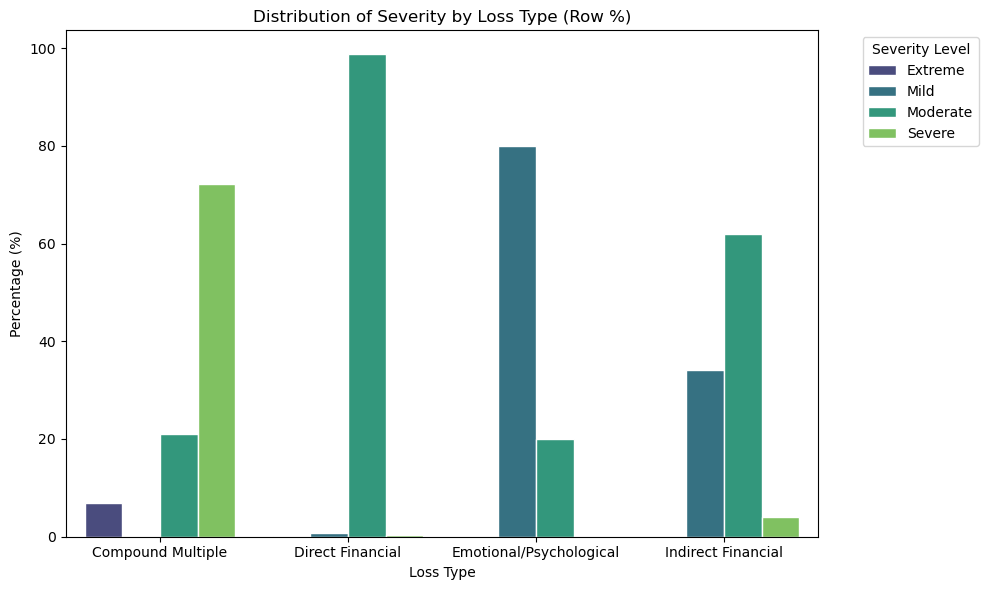

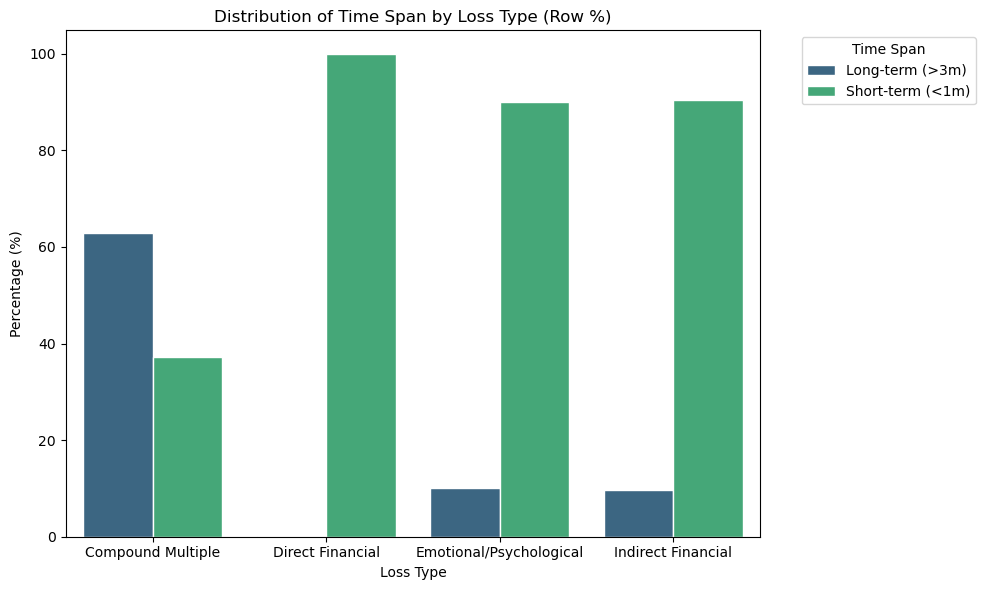

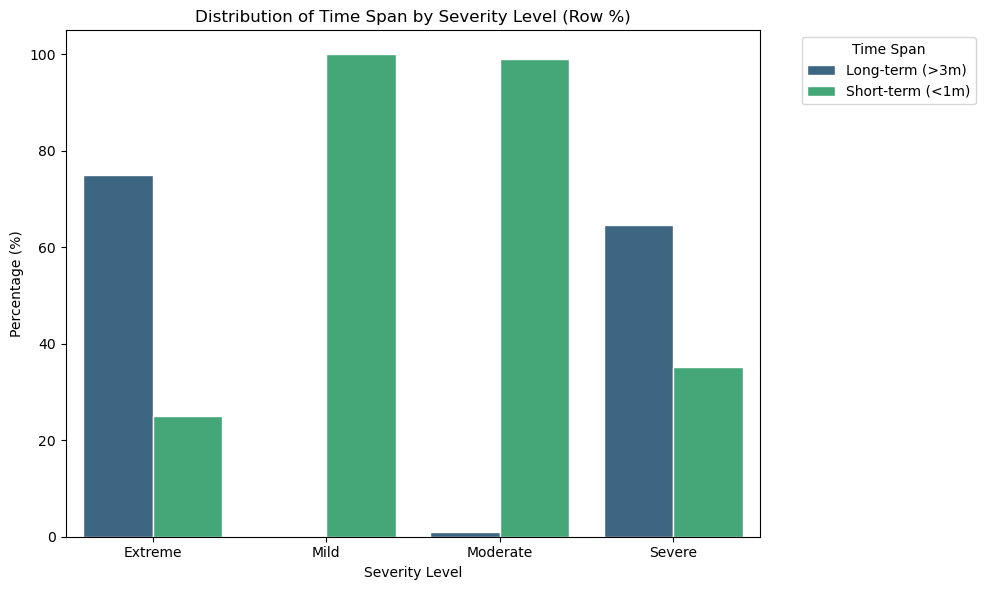

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. 读取数据
df = pd.read_excel("llm_labeled_data.xlsx")

# 2. 标签映射（已100%匹配你的真实标签）
loss_type_map = {
    "直接金钱损失型": "Direct Financial",
    "间接财产损失型": "Indirect Financial",
    "情感/精神损失型": "Emotional/Psychological",
    "复合多重损失型": "Compound Multiple"
}

severity_map = {
    "轻度危害": "Mild",
    "中度危害": "Moderate",
    "重度危害": "Severe",
    "极端危害": "Extreme"
}

time_span_map = {
    "即时一次性损失": "Short-term (<1m)",
    "长期持续损失": "Long-term (>3m)"
}

# 应用映射
df['loss_type'] = df['loss_type'].map(loss_type_map)
df['severity'] = df['severity'].map(severity_map)
df['time_span'] = df['time_span'].map(time_span_map)

# --------------------------
# 3. 用seaborn绘制堆叠柱状图（彻底解决数值类型问题）
# --------------------------
# 1. Loss Type × Severity
cross_1 = pd.crosstab(df['loss_type'], df['severity'], normalize='index') * 100
cross_1 = cross_1.reset_index().melt(id_vars='loss_type', var_name='Severity', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=cross_1, x='loss_type', y='Percentage', hue='Severity', 
            palette='viridis', edgecolor='white')
plt.title("Distribution of Severity by Loss Type (Row %)")
plt.xlabel("Loss Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("stacked_loss_severity_final.png", dpi=300)
plt.show()

# 2. Loss Type × Time Span
cross_2 = pd.crosstab(df['loss_type'], df['time_span'], normalize='index') * 100
cross_2 = cross_2.reset_index().melt(id_vars='loss_type', var_name='Time Span', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=cross_2, x='loss_type', y='Percentage', hue='Time Span', 
            palette='viridis', edgecolor='white')
plt.title("Distribution of Time Span by Loss Type (Row %)")
plt.xlabel("Loss Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Time Span", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("stacked_loss_timespan_final.png", dpi=300)
plt.show()

# 3. Severity × Time Span
cross_3 = pd.crosstab(df['severity'], df['time_span'], normalize='index') * 100
cross_3 = cross_3.reset_index().melt(id_vars='severity', var_name='Time Span', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=cross_3, x='severity', y='Percentage', hue='Time Span', 
            palette='viridis', edgecolor='white')
plt.title("Distribution of Time Span by Severity Level (Row %)")
plt.xlabel("Severity Level")
plt.ylabel("Percentage (%)")
plt.legend(title="Time Span", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("stacked_severity_timespan_final.png", dpi=300)
plt.show()

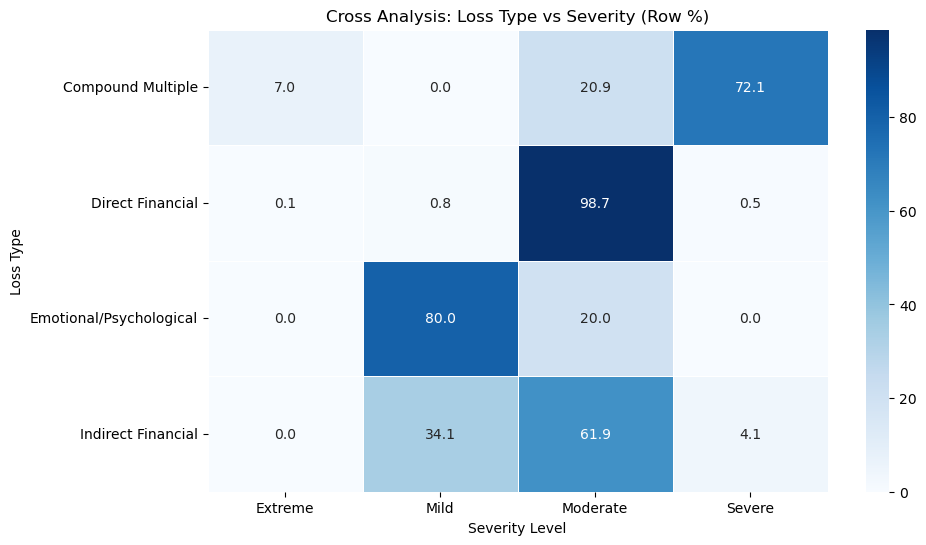

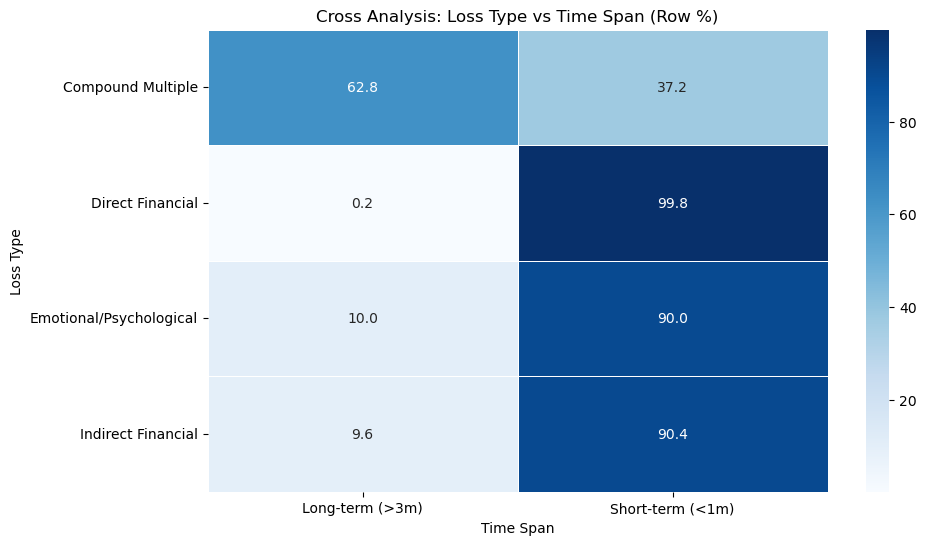

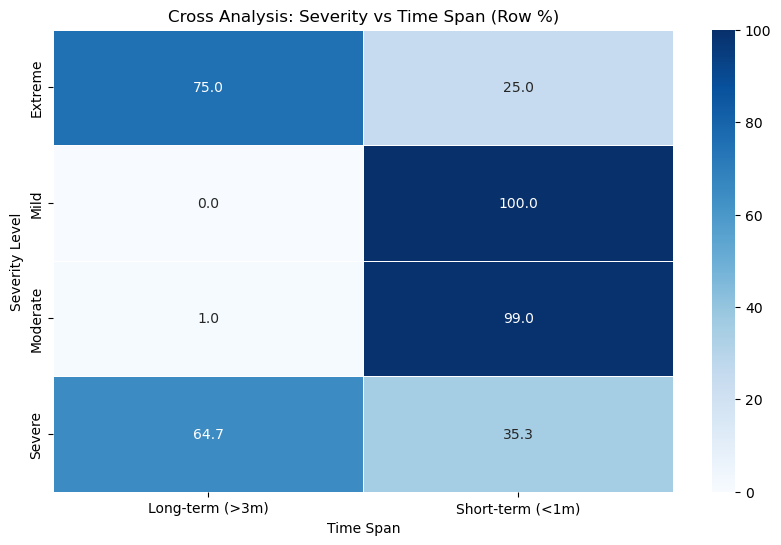

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. 读取数据
df = pd.read_excel("llm_labeled_data.xlsx")

# 2. 标签映射（和堆叠柱状图完全一致）
loss_type_map = {
    "直接金钱损失型": "Direct Financial",
    "间接财产损失型": "Indirect Financial",
    "情感/精神损失型": "Emotional/Psychological",
    "复合多重损失型": "Compound Multiple"
}

severity_map = {
    "轻度危害": "Mild",
    "中度危害": "Moderate",
    "重度危害": "Severe",
    "极端危害": "Extreme"
}

time_span_map = {
    "即时一次性损失": "Short-term (<1m)",
    "长期持续损失": "Long-term (>3m)"
}

# 应用映射
df['loss_type'] = df['loss_type'].map(loss_type_map)
df['severity'] = df['severity'].map(severity_map)
df['time_span'] = df['time_span'].map(time_span_map)

# --------------------------
# 3. 浅色Blues热力图
# --------------------------
# 1. Loss Type × Severity
cross_1 = pd.crosstab(df['loss_type'], df['severity'], normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(cross_1, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title("Cross Analysis: Loss Type vs Severity (Row %)")
plt.xlabel("Severity Level")
plt.ylabel("Loss Type")
plt.savefig("heatmap_loss_severity_blues.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Loss Type × Time Span
cross_2 = pd.crosstab(df['loss_type'], df['time_span'], normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(cross_2, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title("Cross Analysis: Loss Type vs Time Span (Row %)")
plt.xlabel("Time Span")
plt.ylabel("Loss Type")
plt.savefig("heatmap_loss_timespan_blues.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Severity × Time Span
cross_3 = pd.crosstab(df['severity'], df['time_span'], normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(cross_3, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title("Cross Analysis: Severity vs Time Span (Row %)")
plt.xlabel("Time Span")
plt.ylabel("Severity Level")
plt.savefig("heatmap_severity_timespan_blues.png", dpi=300, bbox_inches='tight')
plt.show()